/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda
Loading Saved Models and Training History
✅ Training history loaded successfully!
   Saved on: 2026-03-19 08:34:01
   Training epochs: 15


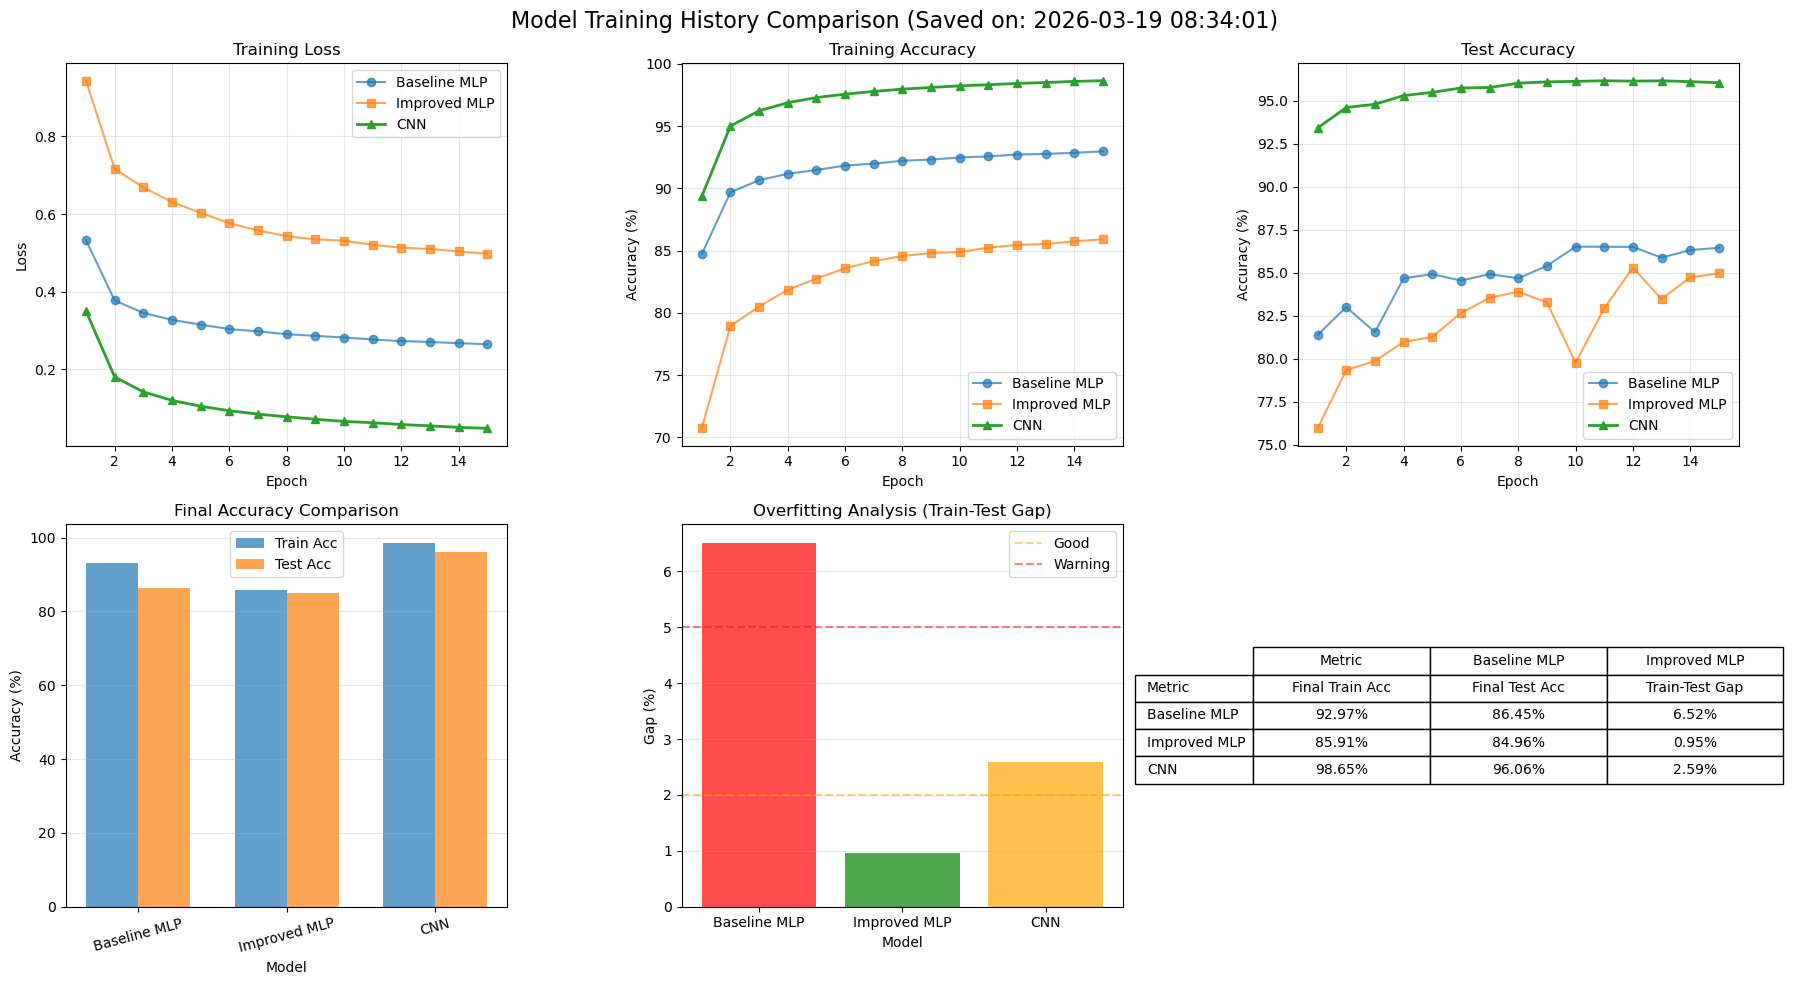


Loading Models
⚠️ Baseline MLP complete model loading failed, trying weights...
❌ Baseline MLP loading failed: Error(s) in loading state_dict for BaselineMLP:
	Missing key(s) in state_dict: "net.0.weight", "net.0.bias", "net.2.weight", "net.2.bias", "net.4.weight", "net.4.bias". 
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias". 
⚠️ Improved MLP complete model loading failed, trying weights...
✅ Improved MLP weights loaded successfully
⚠️ CNN complete model loading failed, trying weights...
❌ CNN loading failed: Error(s) in loading state_dict for CNN:
	size mismatch for classifier.1.weight: copying a param with shape torch.Size([512, 2048]) from checkpoint, the shape in current model is torch.Size([256, 2048]).
	size mismatch for classifier.1.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for classifier.4.weight: copying a param with shape torch.Size([10, 512]) from

100%|██████████| 170M/170M [00:16<00:00, 10.5MB/s] 


✅ Test data loaded successfully! Total 10000 images

Testing Model Performance

📊 Improved MLP Test Results:
   Overall Accuracy: 9.19%

Per-Class Accuracy Analysis

📈 Improved MLP Per-Class Accuracy:
   airplane  : 5.70%
   automobile: 0.10%
   bird      : 10.10%
   cat       : 22.30%
   deer      : 22.60%
   dog       : 4.60%
   frog      : 0.90%
   horse     : 17.80%
   ship      : 6.40%
   truck     : 1.40%

Final Comparison Results


,Model,Test Accuracy,Parameters
0,N/A,N/A,N/A
1,Improved MLP,9.19%,"3,805,450"
2,N/A,N/A,N/A



✅ All tests completed!


In [1]:
# ==================== Run this code in a new ipynb file ====================
# Import necessary libraries
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ==================== Setup Device ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== Setup Save Directory ====================
SAVE_DIR = Path('saved_models')
if not SAVE_DIR.exists():
    raise Exception("❌ saved_models folder not found! Please ensure models have been saved.")

# ==================== Redefine Model Architectures (Must match training) ====================
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class ImprovedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==================== Load Training History ====================
def load_training_history():
    history_path = SAVE_DIR / 'training_history.pkl'
    if history_path.exists():
        with open(history_path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Training history loaded successfully!")
        print(f"   Saved on: {history['metadata']['saved_date']}")
        print(f"   Training epochs: {history['metadata']['epochs']}")
        return history
    else:
        print("❌ Training history file not found")
        return None

# ==================== Load Models ====================
def load_models():
    models = {}
    
    # Method 1: Load complete models (if available)
    complete_paths = {
        'model1': SAVE_DIR / 'model1_complete.pth',
        'model2': SAVE_DIR / 'model2_complete.pth',
        'model3': SAVE_DIR / 'model3_complete.pth'
    }
    
    weights_paths = {
        'model1': SAVE_DIR / 'model1_weights.pth',
        'model2': SAVE_DIR / 'model2_weights.pth',
        'model3': SAVE_DIR / 'model3_weights.pth'
    }
    
    model_classes = {
        'model1': BaselineMLP,
        'model2': ImprovedMLP,
        'model3': CNN
    }
    
    model_names = {
        'model1': 'Baseline MLP',
        'model2': 'Improved MLP',
        'model3': 'CNN'
    }
    
    for model_id, model_class in model_classes.items():
        # Try loading complete model first
        if complete_paths[model_id].exists():
            try:
                model = torch.load(complete_paths[model_id], map_location=device)
                models[model_id] = model
                print(f"✅ {model_names[model_id]} complete model loaded successfully")
            except:
                print(f"⚠️ {model_names[model_id]} complete model loading failed, trying weights...")
        
        # If complete model loading failed, try loading weights
        if model_id not in models and weights_paths[model_id].exists():
            try:
                model = model_class().to(device)
                model.load_state_dict(torch.load(weights_paths[model_id], map_location=device))
                model.eval()
                models[model_id] = model
                print(f"✅ {model_names[model_id]} weights loaded successfully")
            except Exception as e:
                print(f"❌ {model_names[model_id]} loading failed: {e}")
    
    return models

# ==================== Prepare Test Data ====================
def prepare_test_loader(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    test_dataset = datasets.CIFAR10(
        root='./data', 
        train=False, 
        download=True, 
        transform=transform
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=2
    )
    
    print(f"✅ Test data loaded successfully! Total {len(test_dataset)} images")
    return test_loader, test_dataset.classes

# ==================== Test Model Performance ====================
def test_model(model, test_loader, model_name):
    model.eval()
    correct = 0
    total = 0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Per-class accuracy
            c = (predicted == labels).squeeze()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1
    
    overall_acc = 100 * correct / total
    print(f"\n📊 {model_name} Test Results:")
    print(f"   Overall Accuracy: {overall_acc:.2f}%")
    
    return overall_acc, class_correct, class_total

# ==================== Visualization Functions ====================
def visualize_training_history(history):
    """Visualize training history"""
    m1 = history['model1']
    m2 = history['model2']
    m3 = history['model3']
    epochs = history['metadata']['epochs']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Model Training History Comparison (Saved on: {history["metadata"]["saved_date"]})', fontsize=16)
    
    # 1. Training Loss
    ax = axes[0, 0]
    ax.plot(range(1, epochs+1), m1['train_loss'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_loss'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_loss'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Training Accuracy
    ax = axes[0, 1]
    ax.plot(range(1, epochs+1), m1['train_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Test Accuracy
    ax = axes[0, 2]
    ax.plot(range(1, epochs+1), m1['test_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['test_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['test_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Test Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Final Accuracy Comparison
    ax = axes[1, 0]
    models = ['Baseline MLP', 'Improved MLP', 'CNN']
    train_acc_final = [m1['train_acc'][-1], m2['train_acc'][-1], m3['train_acc'][-1]]
    test_acc_final = [m1['test_acc'][-1], m2['test_acc'][-1], m3['test_acc'][-1]]
    
    x = range(len(models))
    width = 0.35
    ax.bar([i - width/2 for i in x], train_acc_final, width, label='Train Acc', alpha=0.7)
    ax.bar([i + width/2 for i in x], test_acc_final, width, label='Test Acc', alpha=0.7)
    ax.set_title('Final Accuracy Comparison')
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. Overfitting Analysis
    ax = axes[1, 1]
    gaps = [m1['train_acc'][-1] - m1['test_acc'][-1],
            m2['train_acc'][-1] - m2['test_acc'][-1],
            m3['train_acc'][-1] - m3['test_acc'][-1]]
    
    colors = ['red' if g > 5 else 'orange' if g > 2 else 'green' for g in gaps]
    ax.bar(models, gaps, color=colors, alpha=0.7)
    ax.set_title('Overfitting Analysis (Train-Test Gap)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Gap (%)')
    ax.axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Good')
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Warning')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Training History Summary Table
    ax = axes[1, 2]
    ax.axis('off')
    summary_data = {
        'Metric': ['Final Train Acc', 'Final Test Acc', 'Train-Test Gap'],
        'Baseline MLP': [f"{m1['train_acc'][-1]:.2f}%", f"{m1['test_acc'][-1]:.2f}%", 
                        f"{m1['train_acc'][-1] - m1['test_acc'][-1]:.2f}%"],
        'Improved MLP': [f"{m2['train_acc'][-1]:.2f}%", f"{m2['test_acc'][-1]:.2f}%",
                        f"{m2['train_acc'][-1] - m2['test_acc'][-1]:.2f}%"],
        'CNN': [f"{m3['train_acc'][-1]:.2f}%", f"{m3['test_acc'][-1]:.2f}%",
               f"{m3['train_acc'][-1] - m3['test_acc'][-1]:.2f}%"]
    }
    
    table = ax.table(cellText=list(summary_data.values()), 
                     rowLabels=list(summary_data.keys()),
                     colLabels=['Metric', 'Baseline MLP', 'Improved MLP', 'CNN'],
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    plt.tight_layout()
    plt.show()

# ==================== Main Program ====================
def main():
    print("="*60)
    print("Loading Saved Models and Training History")
    print("="*60)
    
    # 1. Load training history
    history = load_training_history()
    if history:
        visualize_training_history(history)
    
    # 2. Load models
    print("\n" + "="*60)
    print("Loading Models")
    print("="*60)
    models = load_models()
    
    # 3. Prepare test data
    print("\n" + "="*60)
    print("Preparing Test Data")
    print("="*60)
    test_loader, classes = prepare_test_loader()
    
    # 4. Test models
    print("\n" + "="*60)
    print("Testing Model Performance")
    print("="*60)
    
    results = {}
    model_names = {
        'model1': 'Baseline MLP',
        'model2': 'Improved MLP',
        'model3': 'CNN'
    }
    
    for model_id, model in models.items():
        if model:
            acc, class_correct, class_total = test_model(model, test_loader, model_names[model_id])
            results[model_id] = {
                'name': model_names[model_id],
                'accuracy': acc,
                'class_correct': class_correct,
                'class_total': class_total
            }
    
    # 5. Display per-class accuracy
    if results:
        print("\n" + "="*60)
        print("Per-Class Accuracy Analysis")
        print("="*60)
        
        for model_id, result in results.items():
            print(f"\n📈 {result['name']} Per-Class Accuracy:")
            for i, class_name in enumerate(classes):
                if result['class_total'][i] > 0:
                    class_acc = 100 * result['class_correct'][i] / result['class_total'][i]
                    print(f"   {class_name:10s}: {class_acc:.2f}%")
    
    # 6. Final comparison table
    print("\n" + "="*60)
    print("Final Comparison Results")
    print("="*60)
    
    comparison_df = pd.DataFrame({
        'Model': [results['model1']['name'] if 'model1' in results else 'N/A',
                  results['model2']['name'] if 'model2' in results else 'N/A',
                  results['model3']['name'] if 'model3' in results else 'N/A'],
        'Test Accuracy': [f"{results['model1']['accuracy']:.2f}%" if 'model1' in results else 'N/A',
                         f"{results['model2']['accuracy']:.2f}%" if 'model2' in results else 'N/A',
                         f"{results['model3']['accuracy']:.2f}%" if 'model3' in results else 'N/A'],
        'Parameters': [f"{sum(p.numel() for p in models['model1'].parameters()):,}" if 'model1' in models else 'N/A',
                      f"{sum(p.numel() for p in models['model2'].parameters()):,}" if 'model2' in models else 'N/A',
                      f"{sum(p.numel() for p in models['model3'].parameters()):,}" if 'model3' in models else 'N/A']
    })
    
    display(comparison_df)
    
    print("\n✅ All tests completed!")

# ==================== Run Main Program ====================
if __name__ == "__main__":
    main()